## COE Final Project Part 3 - Group (Conner Jaquess, Wilson Serrano)
# Section 1: Review of Part 2

In part 2, we selected the mechanical system with high dampening. The methods we originally chose were weak in its usage of basic Newton-Raphson and lack of adaptive step sizing. When an equation is stiff, like how the mechanical system dampens extremely quickly at the beginning, we need to dampen Newton-Raphson to reduce error and adapt step sizes to reduce unneeded computation while maintaining accuracy.

# Section 2: Newton-Raphson Damping Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In this function, we will use damping in our Newton Raphson equation to overcome the stiffness of the highly dampened mechanical system. To do this, we introduce the damping factor $0 < \alpha \leq 1$ that adjusts the step size of each Newton-Raphson step. We take a tolerance and halve $\alpha$ for each iteration to move closer to the root for each step. 

Essentially, this allows us to have a very small step size for the beginning (the stiff part of the equation) and have a normal-sized size (e.g. $\alpha = 1$) for the rest. We don't allow the function to miss any roots at the beginning or increase residuals compared to the start of the iteration.

In [2]:
def damped_newton_raphson(y_n, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n
    t_next = h
    num_backtracks = 0
    damping_needed = False
    residuals = []
    alphas = [] # To find final alpha
    
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
        residuals.append(abs(g))
        
        if abs(g) < tol:
            return y_guess, k, True, num_backtracks, damping_needed, residuals, alphas
        
        g_prime = g_prime_func(h)
        delta = -g / g_prime
        
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
        
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
            
            if g_new < g_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0
            num_backtracks += 1
            damping_needed = True
            alphas.append(alpha)
            
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False, num_backtracks, damping_needed, residuals, alphas
        
        y_guess = y_new
    
    return y_guess, max_iter, False, num_backtracks, damping_needed, residuals, alphas




def adaptive_implicit_euler(f, g_func, g_prime_func, y0, t0, t_final, h0, tol):
    """
    Adaptive Euler's Backward with damped Newton-Raphson
    
    Parameters:
    - f: ODE function
    - y0: initial condition
    - t0, t_final: time span
    - h0: initial step size
    - tol: error tolerance
    - h_min, h_max: step size bounds
    - nr_tol: Newton-Raphson tolerance
    - max_nr_iter: max NR iterations
    
    Returns:
    - t: time points (non-uniform!)
    - y: solution values
    - h_history: step sizes used
    - stats: dictionary with performance statistics
    """
    
    # Initialize
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    residuals_list = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }
    
    # Main loop
    while t[-1] < t_final:
        t_n = t[-1]
        y_n = y[-1]
        t_next = t_n + h
        
        # Store stats and solutions
        y_next, k, success, backtracks, damped, residuals, alphas = \
            damped_newton_raphson(y_n, h, g_func, g_prime_func)
        
        if not success:
            print(f"Convergence failed at t={t_next}")
            break
            
        t.append(t_next)
        y.append(y_next)
        residuals_list.append(residuals)
        
        # Update stats
        stats['accepted_steps'] += 1
        stats['nr_iterations'].append(k)
        if damped:
            stats['damping_used'] += 1
    
    return np.array(t), np.array(y), h_history, stats, residuals_list

In [3]:
# This is the ODE for the mechanical system with high damping.
# y is displacement and t is time.
def f(t, y):
    return -5000*y + 0.002*np.sin(t)

# Residual function
def g_func(y_guess, y_n, t_next, h):
    return y_guess - y_n - h * (-5000 * y_guess + 0.002 * np.sin(t_next))

# Derivative of residual function
def g_prime_func(h):
    return 1 + 5000 * h


In [4]:
# Basic implementation

t0 = 0
tf = 0.01
y0 = 1.0
h = 0.0005
t_values = np.arange(t0, tf + h, h)
y_values = np.zeros(len(t_values))
y_values[0] = y0

t, y, h_history, stats, residuals = adaptive_implicit_euler(f, g_func, g_prime_func, y0, t0, tf, h, tol=1e-8)

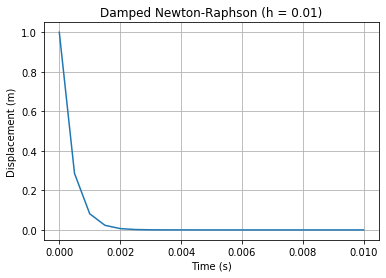

{'accepted_steps': 20, 'rejected_steps': 0, 'nr_iterations': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], 'damping_used': 0, 'function_evals': 0}


In [5]:
plt.plot(t, y)
plt.title('Damped Newton-Raphson (h = 0.01)')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.grid()
plt.show()

print(stats)

At this point it's hard to visualize such extreme oscillation like this with a normal graph, but we can see in basic composition that a much larger step size of h = 0.01 that wouldn't have worked in part 2 is sufficient here. If we had done this the way we did in part 2 with the same step size (no damping), it would've exploded. *For the comparison required by the rubric between damped and normal NR, refer to the graphs in section 4.*

The graph below proves convergence:

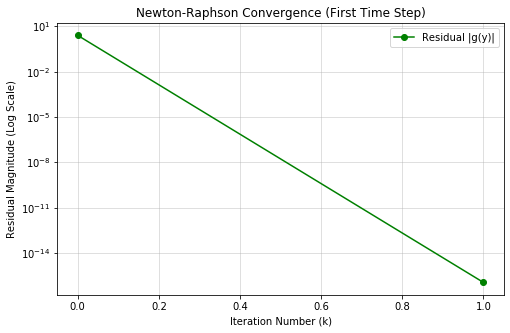

In [6]:
# Stiffest part of equation
first_step_residuals = residuals[0]

plt.figure(figsize=(8, 5))
# Plot the specific list for that one step
plt.semilogy(first_step_residuals, '-o', color='green', label='Residual |g(y)|')

plt.title('Newton-Raphson Convergence (First Time Step)')
plt.xlabel('Iteration Number (k)')
plt.ylabel('Residual Magnitude (Log Scale)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

This shows how quickly error goes to zero. It only takes one iteration.

Now, perhaps the most important thing to note here is that damping was not needed. That is because of the equation being linear. We will provide a quick example of how a nonlinear equation would, in fact, use damping.

In [7]:
def g_nonlinear(y, y_n, t, h):
    return y**3 - y_n 

def g_prime_nonlinear(y):
    return 3.0 * (y**2)

y_val, k, success, backtracks, damped, res, alphas = \
    damped_newton_raphson(2, 0.1, g_nonlinear, g_prime_nonlinear)

print(f"Damping Triggered: {damped}")
print(f"Backtracks: {backtracks}")

Damping Triggered: True
Backtracks: 110


Because this differential equation was nonlinear, damping had to be used.

# Section 3: Adaptive Step Size Implementation

Now, we will implement a method to determine the efficiency of our chosen step size. Using step-doubling error estimation, we will take the difference between the value of a full step size and two steps with a halved size. The value that gives the closest to the tolerance is the sweet spot.

In [8]:
def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    """
    Estimate error using step-doubling (Richardson extrapolation)
    
    1. Take ONE step of size h
    2. Take TWO steps of size h/2
    3. Compare the results
    
    Parameters:
    - y_n: current solution value
    - t_n: current time
    - h: step size to try
    - nr_solver: function that takes one implicit Euler step
    
    Returns:
    - y_full: result from single step (less accurate)
    - y_half: result from two half-steps (more accurate)
    - error: estimated local error
    """
    # Single step of size h
    y_full, k_f, success_f, _, _, _, _ = damped_newton_raphson(y_n, h, g_func, g_prime_func)
    
    # Two half-steps of size h/2
    y_h1, k_h1, success_h1, _, _, _, _ = damped_newton_raphson(y_n, h/2, g_func, g_prime_func)
    y_half, k_h2, success_h2, _, _, _, _ = damped_newton_raphson(y_h1, h/2, g_func, g_prime_func)
    
    # Error estimate
    error = abs(y_half - y_full)
    
    # Total NR iterations for this error estimate
    total_iters = k_f + k_h1 + k_h2
    
    return y_full, y_half, error, total_iters







def adaptive_step(y_n, t_n, h, tol, nr_solver, 
                  h_min=1e-8, h_max=1.0, safety=0.9):
    """
    Take one adaptive step with error control
    
    Returns:
    - y_next: accepted solution value
    - h_used: step size that was accepted
    - h_new: suggested step size for next step
    - accepted: True if step was accepted
    - iters: total NR iterations used
    """
    # Try the step with error estimation
    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver
    )
    
    # Compute new step size suggestion
    if error < 1e-14:  # Error very small
        h_new = min(2.0 * h, h_max)
    else:
        # Standard formula: h_new = h * sqrt(tol/err)
        h_new = h * np.sqrt(tol / error+1e-28)
        h_new = safety * h_new  # Safety factor
        
        # modified so algorithm can actually run with low tolerance
        h_new = max(0.2*h, min(5*h, h_new))
        h_new = max(1e-12, min(h_max, h_new))
    
    # Also don't let h change too dramatically
    h_new = max(0.2 * h, min(5.0 * h, h_new))
    
    # Accept or reject?
    if error < tol:
        # ACCEPT: use the more accurate two-half-step result
        return y_half, h, h_new, True, iters, error
    else:
        # REJECT: don't update y, suggest smaller h
        return y_n, h, h_new, False, iters, error



In [9]:
def changing_step_euler(f, g_func, g_prime_func, y0, t0, t_final, h0, tol):
    """
    Adaptive Euler's Backward with damped Newton-Raphson (and step size)
    
    Parameters:
    - f: ODE function
    - y0: initial condition
    - t0, t_final: time span
    - h0: initial step size
    - tol: error tolerance
    - h_min, h_max: step size bounds
    - nr_tol: Newton-Raphson tolerance
    - max_nr_iter: max NR iterations
    
    Returns:
    - t: time points (non-uniform!)
    - y: solution values
    - h_history: step sizes used
    - stats: dictionary with performance statistics
    """
    
    # Initialize
    t = [t0]
    y = [y0]
    h = h0
    h_history = []
    residuals_list = []
    
    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'error_history': [],
        't_attempts': [],
        'damping_used': 0,
        'function_evals': 0
    }
    
    # Main loop
    while t[-1] < t_final:
        t_n = t[-1]
        y_n = y[-1]
        
        
        y_next, h_used, h_suggested, accepted, iters, error_val = adaptive_step(
            y_n, t_n, h, tol, damped_newton_raphson
        )
        
        
        if accepted:
            # Update state with accepted results
            t.append(t_n + h_used)
            y.append(y_next)
            h_history.append(h_used)
            
            stats['accepted_steps'] += 1
            # Move forward with the new suggested h
            h = h_suggested 
        else:
            # Reject
            stats['rejected_steps'] += 1
            h = h_suggested
            
        # append stats data
        stats['nr_iterations'].append(iters)
        stats['error_history'].append(error_val) # Track error
        stats['t_attempts'].append(t_n)
        stats['function_evals'] += iters
    
    return np.array(t), np.array(y), h_history, stats

In [10]:
t0 = 0
tf = 0.1
y0 = 1.0
h0 = 0.001
t_values = np.arange(t0, tf + h, h)
y_values = np.zeros(len(t_values))
y_values[0] = y0

t_adapt, y_adapt, h_hist, stats = changing_step_euler(f, g_func, g_prime_func, y0, t0, tf, h0, tol=1e-4)

# Section 4: Performance Analysis

For comparison to a fixed step size, I will be referring to Part 2. With a fixed step size from 0 to 0.1 seconds, we required an h=0.0001. This required 1000 steps. However, a 0.1s simulation with the adaptive step alogrithm only required 116 steps (see below). The reason this happened is because the beginning of the system, with its chaotic, rough oscillation, required more frequent step sizes to maintain accuracy and stability, which mismatched what happens 0.01 seconds in - it no longer needs such small step sizes. So, the very very beginning used small step sizes and everything afterwards had much looser requirements to maintain the same level of accuracy and stability. Below are graphs that demonstrate performance.

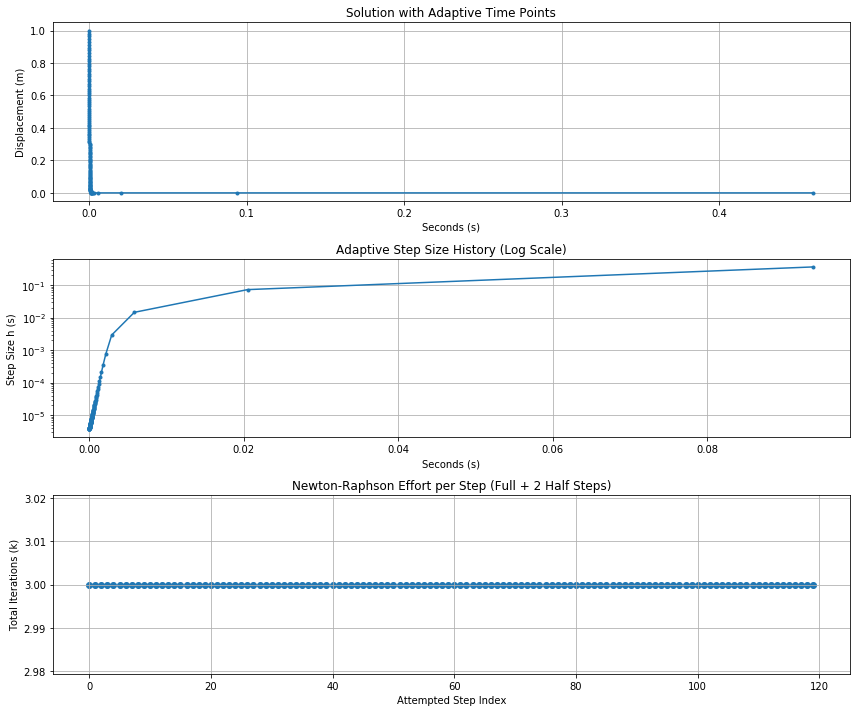

Total Accepted Steps: 116
Total Rejected Steps: 4


In [11]:
plt.figure(figsize=(12, 10))


# Main solution
plt.subplot(3, 1, 1)
plt.plot(t_adapt, y_adapt, '-o', markersize=3)
plt.xlabel('Seconds (s)')
plt.ylabel('Displacement (m)')
plt.title('Solution with Adaptive Time Points')
plt.grid(True)


# Step size history
plt.subplot(3, 1, 2)
plt.semilogy(t_adapt[:-1], h_hist, '-o', markersize=3)
plt.xlabel('Seconds (s)')
plt.ylabel('Step Size h (s)')
plt.title('Adaptive Step Size History (Log Scale)')
plt.grid(True)

# NR Iterations
plt.subplot(3, 1, 3)
plt.scatter(range(len(stats['nr_iterations'])), stats['nr_iterations'], label='NR Iterations')
plt.ylabel('Total Iterations (k)')
plt.xlabel('Attempted Step Index')
plt.title('Newton-Raphson Effort per Step (Full + 2 Half Steps)')
plt.grid(True)

plt.tight_layout()
plt.show()


print(f"Total Accepted Steps: {stats['accepted_steps']}")
print(f"Total Rejected Steps: {stats['rejected_steps']}")

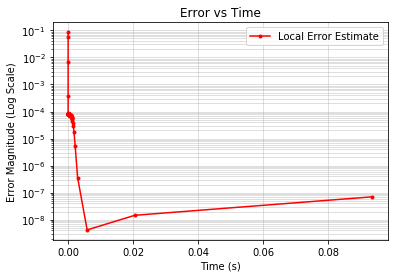

In [12]:
# Error Estimate vs Time
plt.semilogy(stats['t_attempts'], stats['error_history'], 'r-o', markersize=3, label='Local Error Estimate')

plt.xlabel('Time (s)')
plt.ylabel('Error Magnitude (Log Scale)')
plt.title('Error vs Time')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()


|                        | Fixed Step     | Adaptive Step |
|------------------------|----------------|---------------|
| Accepted Steps         | 1000           | 116           |
| Rejected Steps         | 0              | 4             |
| Step Size (h)          | 0.0001         | 0.0001 to 1   |
| NR Iterations per Step | 1              | 3             |
| Total Function Evals   | 1000           | 360           |
| Stability Limit        | $<0.0004s$     | None          |

# Section 5: Robustness Testing

In [13]:
# Large initial h (h=1.0)
h_bigboy = 1.0
t, y, h_hist, stats = changing_step_euler(f, g_func, g_prime_func, y0, t0, tf, h_bigboy, tol=1e-4)

print("Large h, h=1.0")
print(f"First accepted h: {h_hist[0]}")
print(f"Total Rejected Steps: {stats['rejected_steps']}")

Large h, h=1.0
First accepted h: 3.7484378380463173e-06
Total Rejected Steps: 10


In [14]:
# very low tolerance 1e-8
tol_tight = 1e-8
h0 = 0.0001
t0 = 0
tf = 0.0005
t, y, h_hist, stats = changing_step_euler(f, g_func, g_prime_func, y0, t0, tf, h0, tol=tol_tight)

print("Very low tolerance, tol= 1e-8")
print(f"Steps: {stats['accepted_steps']}")

Very low tolerance, tol= 1e-8
Steps: 7928


The algorithm, as we can see with this test, works well even with large initial step sizes and low tolerances. The flexibility of the algorithm allows it to work universally, based off the data we have seen in this project. Of course, an extremely low tolerance requires excessive computation speed and wouldn't work, but it still functions properly. And of course, step sizes are still adjusted as necessary.

# Section 6: Conclusions

To be completely real here, damping wasn't 100% necessary for our system because it wasn't linear. Even a huge step size would not trigger the algorithm, simply because of the equation's form. However, a nonlinear equation like the one we presented above would absolutely need damping to prevent explosion. If we had chosen an equation like that, it asbolutely would have been necessary.

In this project, adaptive step sizes were absolutely beneficial. We saw that it significantly reduced the number of computations (more than halving them) and it would likely do even better in a more complex system. The stiffness opposed to the non-stiffness in this model make adaptive step sizes a very useful and efficient method to use, even if it would appear at first glance to take longer.

The big takeaway here is that, for this system, adaptive step sizing is much more efficient, and in general, damping is a great cushion (particularly for nonlinear equations) to ensure accuracy and stability in computational modeling.

# Bonus 3: Work-Precision Diagram

This little dessert of a section will compare work to precision for different levels of tolerances. We will take a value with extremely low tolerance and essentially use that as an analytical solution to compare more forgiving tolerances with.

In [15]:
#this block is entirely stolen from part 2!

def f(t, y):
    return -5000*y + 0.002*np.sin(t)

def residual_prime(h):
    return 1 + 5000*h


def newton_raphson(y_n, t_next, h, tolerance, max_iterations=20):

    # Using the current y value as the first guess
    future_guess = y_n

    for iteration in range(max_iterations):

        # Residual equation from Backward Euler
        residual = future_guess - y_n - h*f(t_next, future_guess)

        # Check if the guess is already good enough
        if abs(residual) < tolerance:
            return future_guess, iteration

        # Newton-Raphson update
        future_guess = future_guess - residual/residual_prime(h)

    # If it does not converge, return the last guess
    return future_guess, max_iterations

def backwardEuler(t_start, t_end, y_0, h, tolerance):

    # Create time values, y values, and iteration list
    t_values = np.arange(t_start, t_end + h, h)
    y_values = np.zeros(len(t_values))
    iterations_array = []

    # Initial condition
    y_values[0] = y_0

    # Backward Euler loop
    for i in range(1, len(t_values)):

        y_n = y_values[i - 1]
        t_next = t_values[i]

        # Solve for the next y value using Newton-Raphson
        y_values[i], iterations = newton_raphson(y_n, t_next, h, tolerance)
        iterations_array.append(iterations)

    return t_values, y_values, iterations_array

In [16]:
tolerances = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6, 1e-7] #arbitrary tolerances, chosen bc the plot is log-log
h_fixed = [0.01, 0.005, 0.001, 0.0005, 0.0001]
work = []
precision = []

# Our comparison value for error with super low tolerance
_, y_true_arr, _, _ = changing_step_euler(f, g_func, g_prime_func, y0, t0, tf, h0, tol=1e-10)
y_true = y_true_arr[-1]

for tol in tolerances:
    t_arr, y_arr, h_hist, stats = changing_step_euler(f, g_func, g_prime_func, y0, t0, tf, h0, tol)
    
    # Work = Integral of F*dr (jk it's number of Newton-Raphson iterations)
    work.append(np.sum(stats['nr_iterations']))
    
    # Precision = Error (compared to a low tol)
    error = abs(y_arr[-1] - y_true)
    precision.append(error)
    

# Fixed step
work_fixed = []
err_fixed = []
for h in h_fixed:
    t_f, y_f, iterations_f = backwardEuler(t0, tf, y0, h, tolerance=1e-9)
    work_fixed.append(np.sum(iterations_f))
    err_fixed.append(abs(y_f[-1] - y_true))
    

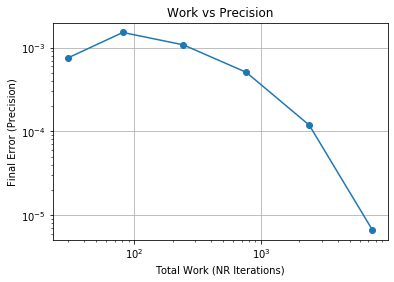

In [17]:
plt.loglog(work, precision, '-o', markersize=6)
plt.xlabel('Total Work (NR Iterations)')
plt.ylabel('Final Error (Precision)')
plt.title('Work vs Precision')
plt.grid()
plt.show()

# The rubric is confusing in asking for several curves of tolerances, but I believe these
# should be data points based off the x and y axes?

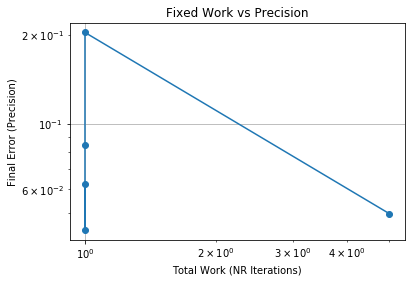

In [18]:
plt.loglog(work_fixed, err_fixed, '-o', markersize=6)
plt.xlabel('Total Work (NR Iterations)')
plt.ylabel('Final Error (Precision)')
plt.title('Fixed Work vs Precision')
plt.grid()
plt.show()

Evidently, the work needed is much less than adaptive algorithms; however, the error is magnitudes higher. Thus, the best option is still adaptive algorithms despite its requirement for a thousand more function evaluations.